In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import timeit
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
from matplotlib import cm
import math
import matplotlib.patches as patches


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Given dynamical system:


We consider the following synthesis problem:
\begin{align*}
\begin{bmatrix}
    \dot{x}_1\\
    \dot{x}_2
\end{bmatrix}=\begin{bmatrix}
    x_2\\
    (x_1-1)-(x_1-1)^3-0.1x_2
\end{bmatrix}+\begin{bmatrix}
    0\\
    1
\end{bmatrix}u
\end{align*}
And the unsafe set to be:
\begin{align*}
    C_1^c=\{(x_1,x_2):(x_1-0)^2+(x_2-3)^2\leq 0.25\} \Rightarrow h(x)=(x_1-3)^2+(x_2-3)^2-0.25\\
    C_2^c = \{(x_1,x_2):(x_1+2)^2+(x_2+2)^2\leq 0.25\} \Rightarrow h(x)=(x_1+2)^2+(x_2+2)^2-0.25
\end{align*}
Assume the point of stability to be $(0,0)$. Then the lie derivatives can be written as:
\begin{align}
    L_fh(x)&=2(x_1-0)x_2+2(x_2-3)[ (x_1-1)-(x_1-1)^3-0.1x_2]\\
    L_gh(x)&=2(x_2-3)
\end{align}
and we will take $\alpha$ to be linear and quadratic.


In [3]:
def f(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = torch.stack(
        [
            x[:,1],
            (x[:,0]-1)-(x[:,0]-1)**3 -0.1 * x[:,1]
        ], dim=1
    )
    return val.squeeze(0) if val.shape[0] == 1 else val

def g(x):
    """Vectorized g(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        torch.zeros_like(x[:, 0]),
        torch.full_like(x[:, 0], 1.0)
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def div_f(x):
    if x.dim() == 1:
        return torch.tensor(-0.1, device=device)
    else:
        return -0.1 * torch.ones(x.shape[0], device=device)
    
def div_g(x):
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)
    
def h(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = (x[:,0]-0)**2 + (x[:,1]-3)**2 - 0.25
    return val.squeeze(0) if val.shape[0] == 1 else val

def h1(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = (x[:,0]+2)**2 + (x[:,1]+2)**2 - 1.0
    return val.squeeze(0) if val.shape[0] == 1 else val


In [4]:

class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),            
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
                

    def forward(self, x):
        return self.net(x)
                

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        if x.dim() == 1:
            return abs(self.linear_layer.bias)
        return abs(self.linear_layer.bias.expand(x.shape[0], -1))

# Define usual loss

In [5]:

def gradient_batch(func, x):
    """Compute gradients for a batch of inputs efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x).sum()
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    return grad

def gradient_batch_special_b(func, x):
    """Compute gradients of ||f(x)||^2 for a batch efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x)
    output_norm_squared = (output ** 2).sum(dim=1).sum()
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    return grad

# ==================== FULLY VECTORIZED CONTROL DENSITY ====================

def control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    """FULLY VECTORIZED - processes entire batch at once"""
    # x = x[h(x)>0]
    batch_size = x.shape[0]
    
    # Compute all values in batch
    divergence_at_f = div_f(x)  # [batch_size]
    divergence_at_g = div_g(x)  # [batch_size]
    
    # Compute gradients for entire batch
    grad_at_a = gradient_batch(a_fun, x)  # [batch_size, 2]
    grad_at_c = gradient_batch(c_fun, x)  # [batch_size, 2]
    grad_at_b = gradient_batch_special_b(b_fun, x)  # [batch_size, 2]
    
    # Compute function values
    a_vals = a_fun(x).squeeze()  # [batch_size]
    c_vals = c_fun(x).squeeze()  # [batch_size]
    f_vals = f(x)  # [batch_size, 2]
    g_vals = g(x)  # [batch_size, 2]
    
    # Vectorized computation of term1
    term1 = (a_vals * divergence_at_f + 
             divergence_at_g * c_vals + 
             (grad_at_a * f_vals).sum(dim=1) + 
             (grad_at_c * g_vals).sum(dim=1))
    
    # Vectorized computation of term2
    scaled_x =  2 * x + grad_at_b  # [batch_size, 2]
    combined = f_vals * a_vals.unsqueeze(1) + g_vals * c_vals.unsqueeze(1)  # [batch_size, 2]
    term2 = (scaled_x * combined).sum(dim=1)
    
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    """Optimized loss computation"""
    divergence = control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    gamma_vals = gamma_fun(x).squeeze()
    
    loss = F.relu(gamma_vals - divergence).mean()
    a_loss = F.relu( - a_fun(x).squeeze()).mean()
    gamma_loss = F.relu(-gamma_vals).mean()
    return loss + a_loss + gamma_loss 

# Define Safety loss

In [6]:
def control_safety_loss(x,a_fun,c_fun,h_fun):
    """Safety loss computation"""
    a_vals = a_fun(x).squeeze()
    c_vals = c_fun(x).squeeze()
    h_vals = h_fun(x).squeeze()
    
    lie_derivative_g = 2 * (x[:,1]-3)
    lie_derivative_f = 2 * (x[:,0]-0)*x[:,1] + 2*(x[:,1]-3)*((x[:,0]-1)-(x[:,0]-1)**3 - 0.1 * x[:,1])

    first_constraint = a_vals * (lie_derivative_f + (h_vals **5))
    second_constraint = c_vals * lie_derivative_g
    safety_loss = F.relu( - (first_constraint + second_constraint)).mean()
    return safety_loss

def control_safety_loss_h1(x,a_fun, c_fun, h_fun1):
    a_vals = a_fun(x).squeeze()
    c_vals = c_fun(x).squeeze()
    h_vals = h_fun1(x).squeeze()

    lie_derivative_g = 2 * (x[:,1]+2)
    lie_derivative_f = 2 * (x[:,0]+2)*x[:,1] + 2*(x[:,1]+2)*((x[:,0]-1)-(x[:,0]-1)**3 - 0.1 * x[:,1])
    
    first_constraint = a_vals * (lie_derivative_f + (h_vals **5))
    second_constraint = c_vals * lie_derivative_g
    safety_loss = F.relu( - (first_constraint + second_constraint)).mean()
    return safety_loss

def l2_for_b(x,b_fun):
    l2_norm = (b_fun(x)**2).mean()
    return l2_norm    


In [7]:
def checkSMTconstraints(vars, a_learnt, divergence_learnt,safety_constraint ,ball_lb,ball_ub, config, epsilon=0):
    ball = Expression(0)
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)

    a_condition = a_learnt >= 0
    safety_constraint = safety_constraint >= 0
    divergence_condition = divergence_learnt > 0

    findal_condition = logical_and(
        logical_imply(ball_in_bound, a_condition),
        logical_imply(ball_in_bound, divergence_condition),  
        logical_imply(ball_in_bound, safety_constraint))
    return CheckSatisfiability(logical_not(findal_condition), config)
  

def AddCounterexamples(x, CE, N, device):
    """Adds counterexamples to the sample set efficiently"""
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)
    
    # Vectorized counterexample addition
    new_points = np.column_stack(nearby)
    new_points_tensor = torch.tensor(new_points, dtype=torch.float32, device=device)
    x = torch.cat((x, new_points_tensor), dim=0)
    x = torch.unique(x, dim=0)
    
    return x, new_points_tensor

In [8]:

class SymbolicNN:
    """Convert neural networks to symbolic expressions for dReal"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights) - 1):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [tanh(zi) for zi in z]
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

class activSymbolicNN:
    """Convert neural networks with sigmoid to symbolic expressions"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights)):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [(1/(1 + exp(-zi))) for zi in z]
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1],
        (vars[0]-1)-(vars[0]-1)**3 - 0.1 * vars[1]
    ]
    g_val = [
        0.0 * vars[0],
        1.0 
    ]
    
    f_div = -0.1
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2

    safety_constraint = (c_sym * 2 * (vars[1]-3) + 
                         a_sym * (2 * (vars[0]-0) * ((vars[0]-1)-(vars[0]-1)**3 - 0.1 * vars[1])) + 
                         a_sym * ((vars[0]-3)**2 + (vars[1]-3)**2 -0.25)**5)
    
    return a_sym, constraint, safety_constraint

In [9]:
def safe_density_training(x, epochs=100, lr=1e-4, ball_lb=0.05, ball_ub=6,check_interval=10):
    """ trains for safe and stable density functions and controller corresponding to it"""
    stability_loss = []
    safety_loss = []
    loss_total= []

    # call the neural networks
    a_net = numerator_polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
    b_net = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
    c_net = polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)

    gamma_net = GammaFunctionNet(input_dim=2, output_dim=1).to(device)
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5

    valid = False
    print("Starting training...")



    iteration_limit = 1000
    while not valid:
        for epoch in range(epochs):
            for iteration in range(iteration_limit):
                optimizer.zero_grad()
                loss_stability = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
                
                loss_safety = control_safety_loss(x, a_net, c_net, h) + control_safety_loss_h1(x, a_net, c_net, h1)

                loss_reg = l2_for_b(x, b_net)
                
                total_loss = loss_stability + 10 * loss_safety + (1e-4) * loss_reg
                total_loss.backward()
                optimizer.step()
            
            if epoch % 1 == 0:
                print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Stability Loss: {loss_stability.item():.6f}, Safety Loss: {loss_safety.item():.6f}, Reg Loss: {loss_reg.item():.6f}")
                stability_loss.append(loss_stability.item())
                safety_loss.append(loss_safety.item())
                loss_total.append(total_loss.item())
            
            # Early stoping if the loss is already 1e-3, can stop
            if total_loss.item() < 1e-3:
                valid = True
                print(" Loss threshold met - stopping early!")
                break
            # # After training epochs, check SMT constraints
            # if epoch % check_interval == 0 and epoch > 0:
            #     print(f"  [Epoch {epoch}] Checking SMT constraints...")
            #     vars = [Variable("x1"), Variable("x2")]
                
            #     try:
            #         a_learnt, divergence_learnt, safety_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
            #         CE = checkSMTconstraints(vars, a_learnt, divergence_learnt,safety_learnt ,ball_lb, ball_ub, config)
                    
            #         if CE:
            #             print(f" Counterexample found! Adding 100 new points...")
            #             x_before = x.shape[0]
            #             x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
            #             x_after = x.shape[0]
            #             print(f"  Dataset size: {x_before} to {x_after} (+{x_after - x_before} unique)")
            #         else:
            #             valid = True
            #             print(" No counterexample found - constraints satisfied!")
            #             break
            #     except Exception as e:
            #         print(f"   SMT check failed: {e}")
            #         continue

    print("Training completed with valid constraints.")
    return a_net, b_net, c_net, stability_loss, safety_loss, loss_total

def stable_only_control_training(x, epochs=100, lr=1e-4, ball_lb=0.01,ball_ub=6, check_interval=10):
    """trains for only stable density functions and controller corresponding to it"""
    stability_loss = []
    loss_total= []
    # call the neural networks
    a_net = numerator_polynomial_net(input_dim=2, hidden_dim=32, output_dim=1).to(device)
    b_net = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
    c_net = polynomial_net(input_dim=2, hidden_dim=32, output_dim=1).to(device)
    gamma_net = GammaFunctionNet(input_dim=2, output_dim=1).to(device)
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5

    valid = False
    print("Starting training...")
    iteration_limit = 500
    while not valid:
        for epoch in range(epochs):
            for iteration in range(iteration_limit):
                optimizer.zero_grad()
                loss_stability = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
                loss_reg = l2_for_b(x, b_net)
                total_loss = loss_stability + (1e-4) * loss_reg
                total_loss.backward()
                optimizer.step()
            if epoch % 1 == 0:
                print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Stability Loss: {loss_stability.item():.6f}, Reg Loss: {loss_reg.item():.6f}")
                stability_loss.append(loss_stability.item())
                loss_total.append(total_loss.item())

            # Early stoping if the loss is already 1e-3, can stop
            if total_loss.item() < 1e-3:
                valid = True
                print(" Loss threshold met - stopping early!")
                break                
            # After training epochs, check SMT constraints
            # if epoch % check_interval == 0 and epoch > 0:
            #     print(f"  [Epoch {epoch}] Checking SMT constraints...")
            #     vars = [Variable("x1"), Variable("x2")]
                
            #     try:
            #         a_learnt, divergence_learnt, _ = candidate_constraint_learnt(vars, a_net, b_net, c_net)
            #         CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, Expression(1), ball_lb, ball_ub, config)
                    
            #         if CE:
            #             print(f" Counterexample found! Adding 100 new points...")
            #             x_before = x.shape[0]
            #             x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
            #             x_after = x.shape[0]
            #             print(f"  Dataset size: {x_before} to {x_after} (+{x_after - x_before} unique)")
            #         else:
            #             valid = True
            #             print(" No counterexample found - constraints satisfied!")
            #             break
            #     except Exception as e:
            #         print(f"   SMT check failed: {e}")
            #         continue
    print("Training completed with valid constraints.")
    return a_net, b_net, c_net, stability_loss, loss_total


In [10]:

def plot_results(risks, labels):
    """Plot risk curves"""
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()

def plot_stable_safe_density_contours(a_nn, b_nn, c_nn, density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = (1e+5)*a_nn(grid_points) / (torch.exp(
            torch.sum( grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X-0)**2 + (Y-3)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    
    unsafe_region2 = (X+2)**2 + (Y+2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region2, levels=[0.5, 1], colors='black', alpha=0.99)
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Mask the velocity field inside the unsafe region
        unsafe_mask = (X_flow - 0)**2 + (Y_flow - 3)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]

        # another unsafe region is (-2,-2)
        unsafe_mask = (X_flow + 2)**2 + (Y_flow + 2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]        
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax


def plot_stable_density_contours(a_nn, b_nn, c_nn, density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = (1e+5)*a_nn(grid_points) / (torch.exp(
            torch.sum(grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        # Normalize the velocity field
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / (magnitude + 1e-9)
        DY = DY / (magnitude + 1e-9)
        
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax

In [11]:
# create dataset for safe and stable density controller

torch.cuda.empty_cache()
torch.manual_seed(42)
random.seed()

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float().to(device)


Using device: cuda:1


In [24]:
a_safe, b_safe, c_safe, stability_loss_safe, safety_loss_safe, total_loss_safe = safe_density_training(numerical_x, epochs=60, lr=1e-4, ball_lb=0.05, ball_ub=6, check_interval=30)



Starting training...
Epoch 0, Total Loss: 4.659372, Stability Loss: 0.785058, Safety Loss: 0.387242, Reg Loss: 18.916777
Epoch 1, Total Loss: 1.306265, Stability Loss: 0.168602, Safety Loss: 0.113589, Reg Loss: 17.682602
Epoch 2, Total Loss: 0.314118, Stability Loss: 0.051123, Safety Loss: 0.026132, Reg Loss: 16.757416
Epoch 3, Total Loss: 0.113595, Stability Loss: 0.017515, Safety Loss: 0.009446, Reg Loss: 16.226933
Epoch 4, Total Loss: 0.070250, Stability Loss: 0.005240, Safety Loss: 0.006343, Reg Loss: 15.811477
Epoch 5, Total Loss: 0.050137, Stability Loss: 0.001945, Safety Loss: 0.004664, Reg Loss: 15.508103
Epoch 6, Total Loss: 0.037094, Stability Loss: 0.000775, Safety Loss: 0.003476, Reg Loss: 15.595719
Epoch 7, Total Loss: 0.027065, Stability Loss: 0.000624, Safety Loss: 0.002489, Reg Loss: 15.488440
Epoch 8, Total Loss: 0.019635, Stability Loss: 0.000243, Safety Loss: 0.001786, Reg Loss: 15.351107
Epoch 9, Total Loss: 0.013936, Stability Loss: 0.000247, Safety Loss: 0.001215,

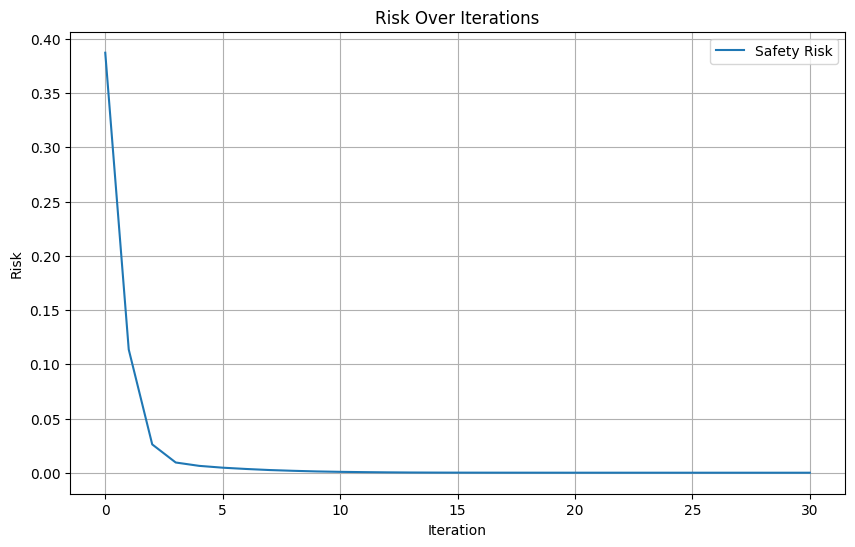

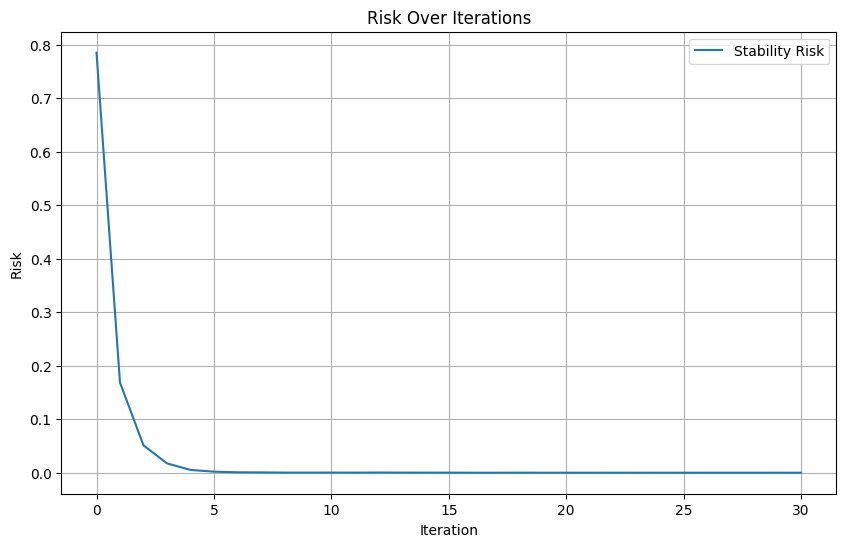

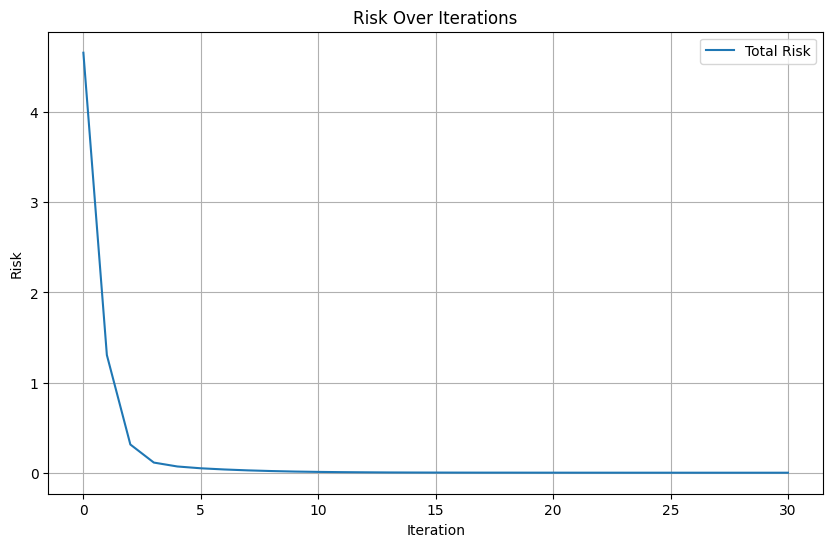

In [25]:
safety_risk, stability_risk, total_risk = [safety_loss_safe], [stability_loss_safe], [total_loss_safe]
plot_results(safety_risk, labels=["Safety Risk"])
plot_results(stability_risk, labels=["Stability Risk"])
plot_results(total_risk, labels=["Total Risk"])

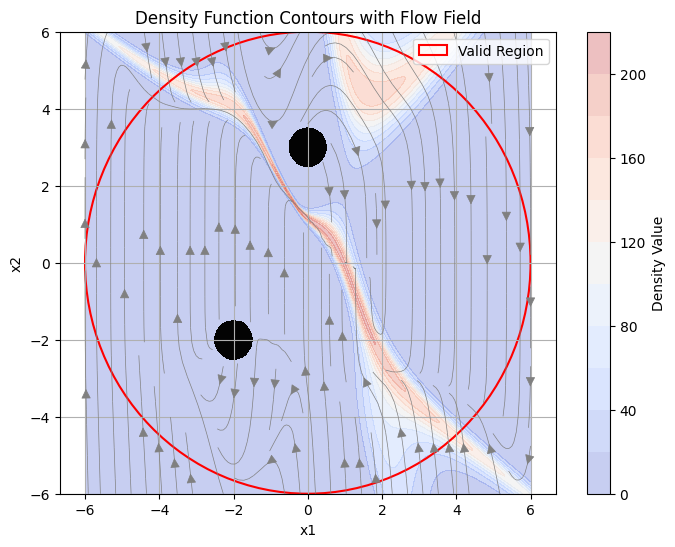

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [26]:
plot_stable_safe_density_contours(a_safe, b_safe, c_safe, density_threshold=0.1, device=device, plot_flow=True)


In [27]:
# save the models
torch.save(a_safe.state_dict(), "a_safe_model.pth")
torch.save(b_safe.state_dict(), "b_safe_model.pth")
torch.save(c_safe.state_dict(), "c_safe_model.pth")

In [12]:
# create dataset for safe and stable density controller

torch.cuda.empty_cache()
torch.manual_seed(58)
random.seed()

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float().to(device)


Using device: cuda:1


In [13]:
a_safe1, b_safe1, c_safe1, stability_loss_safe1, safety_loss_safe1, total_loss_safe1 = safe_density_training(numerical_x, epochs=60, lr=1e-4, ball_lb=0.05, ball_ub=6, check_interval=30)



Starting training...
Epoch 0, Total Loss: 4.856784, Stability Loss: 0.707612, Safety Loss: 0.414728, Reg Loss: 18.897575
Epoch 1, Total Loss: 1.036702, Stability Loss: 0.076833, Safety Loss: 0.095780, Reg Loss: 20.669016
Epoch 2, Total Loss: 0.293026, Stability Loss: 0.029964, Safety Loss: 0.026107, Reg Loss: 19.907356
Epoch 3, Total Loss: 0.147451, Stability Loss: 0.017062, Safety Loss: 0.012843, Reg Loss: 19.610188
Epoch 4, Total Loss: 0.100656, Stability Loss: 0.006904, Safety Loss: 0.009182, Reg Loss: 19.341705
Epoch 5, Total Loss: 0.074225, Stability Loss: 0.003109, Safety Loss: 0.006924, Reg Loss: 18.728790
Epoch 6, Total Loss: 0.048077, Stability Loss: 0.002417, Safety Loss: 0.004387, Reg Loss: 17.924809
Epoch 7, Total Loss: 0.020215, Stability Loss: 0.001982, Safety Loss: 0.001647, Reg Loss: 17.593493
Epoch 8, Total Loss: 0.012882, Stability Loss: 0.000235, Safety Loss: 0.001085, Reg Loss: 18.011707
Epoch 9, Total Loss: 0.009916, Stability Loss: 0.000059, Safety Loss: 0.000801,

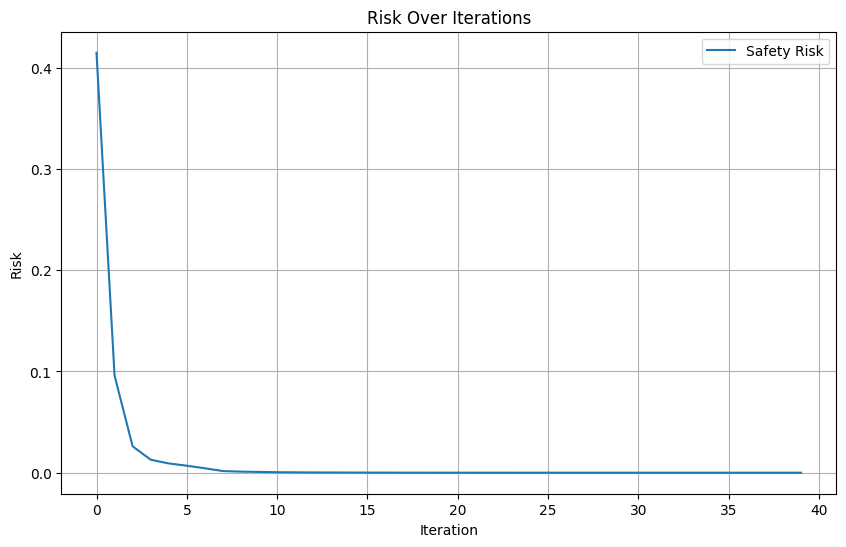

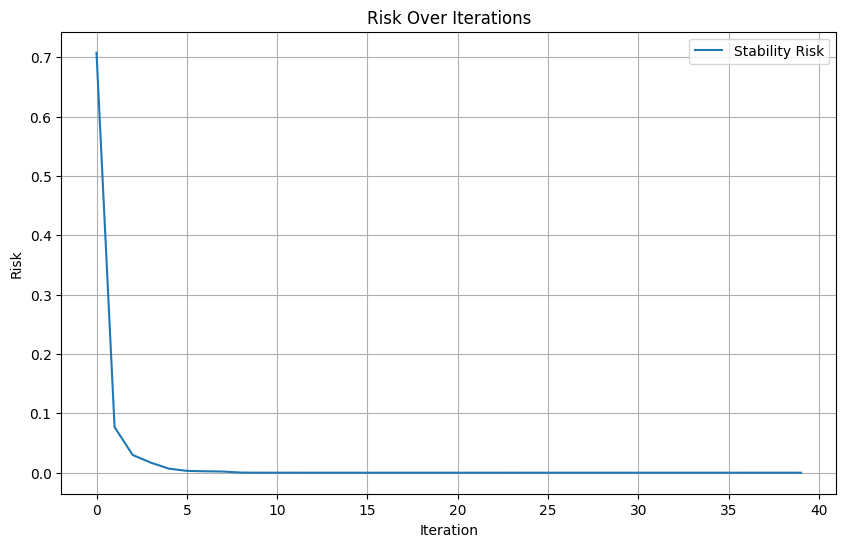

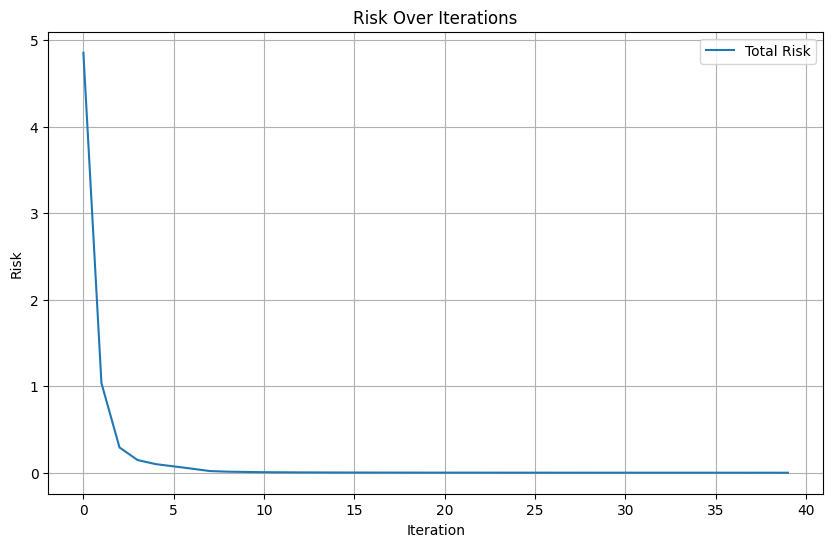

In [14]:
safety_risk, stability_risk, total_risk = [safety_loss_safe1], [stability_loss_safe1], [total_loss_safe1]
plot_results(safety_risk, labels=["Safety Risk"])
plot_results(stability_risk, labels=["Stability Risk"])
plot_results(total_risk, labels=["Total Risk"])

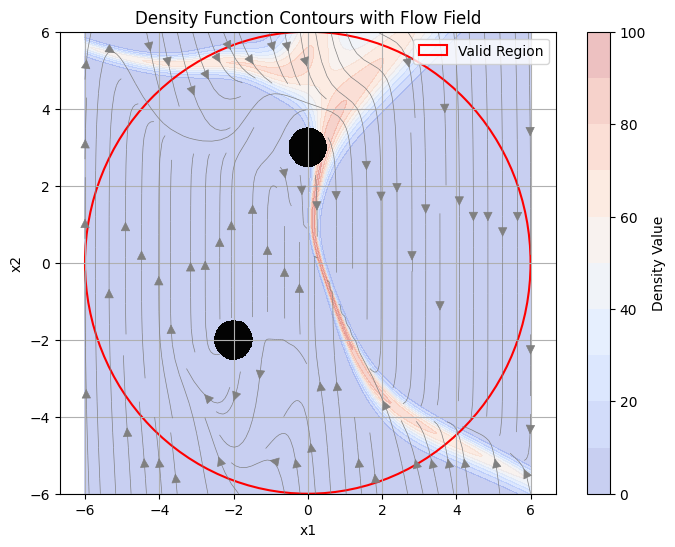

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [15]:
plot_stable_safe_density_contours(a_safe1, b_safe1, c_safe1, density_threshold=0.1, device=device, plot_flow=True)


In [17]:
torch.save(a_safe1.state_dict(), "a_safe_model1.pth")
torch.save(b_safe1.state_dict(), "b_safe_model1.pth")
torch.save(c_safe1.state_dict(), "c_safe_model1.pth")

# Mixing safe - stable with safe-stable controllers
here as titile suggest we mix safe-stable controllers with stable controller

## load the network

we will first test mixing only the safe controller for common obstacle

In [12]:
# load a_safe_models, b_safe_models, c_safe_models and plot the density contours together
a_safe_model = numerator_polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
a_safe_model.load_state_dict(torch.load("a_safe_model.pth"))
b_safe_model = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
b_safe_model.load_state_dict(torch.load("b_safe_model.pth"))
c_safe_model = polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
c_safe_model.load_state_dict(torch.load("c_safe_model.pth"))

a_safe_model1 = numerator_polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
a_safe_model1.load_state_dict(torch.load("a_safe_model1.pth"))
b_safe_model1 = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
b_safe_model1.load_state_dict(torch.load("b_safe_model1.pth"))
c_safe_model1 = polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
c_safe_model1.load_state_dict(torch.load("c_safe_model1.pth"))


/tmp/ipykernel_80138/3916071197.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_safe_model.load_state_dict(torch.load("a_safe_model.pth"))
/tmp/ipykernel_80138/3916071

<All keys matched successfully>

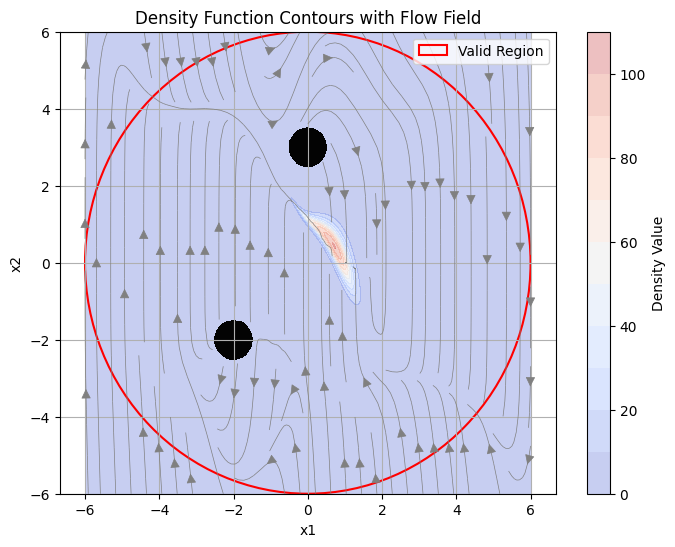

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [13]:
plot_stable_safe_density_contours(a_safe_model, b_safe_model, c_safe_model, density_threshold=0.1, device=device, plot_flow=True)


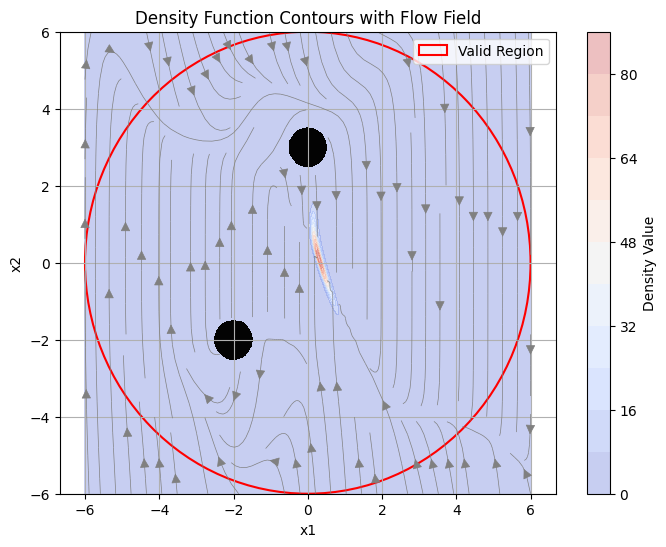

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [14]:
plot_stable_safe_density_contours(a_safe_model1, b_safe_model1, c_safe_model1, density_threshold=0.1, device=device, plot_flow=True)


## plot the mixed density and control

\begin{align}
    \rho^*&= \sum_i  \rho_i\\
    u^*&= \frac{1}{\rho^*} \sum_i \rho_i u_i\\
    &= \frac{\sum_i \psi}{\sum_i \rho_i}=\frac{\sum_i \frac{c_i}{\exp(||x||^2+||b_i||^2)}}{\sum_i \frac{a_i}{\exp(||x||^2+||b_i||^2)}}\\
\end{align}
for mixing of two controllers:
\begin{align}
    u^*=\frac{\exp(||x||^2+||b_2||^2)c_1 + \exp(||x||^2+||b_1||^2)c_2}{\exp(||x||^2+||b_2||^2)a_1 + \exp(||x||^2+||b_1||^2)a_2}
\end{align}

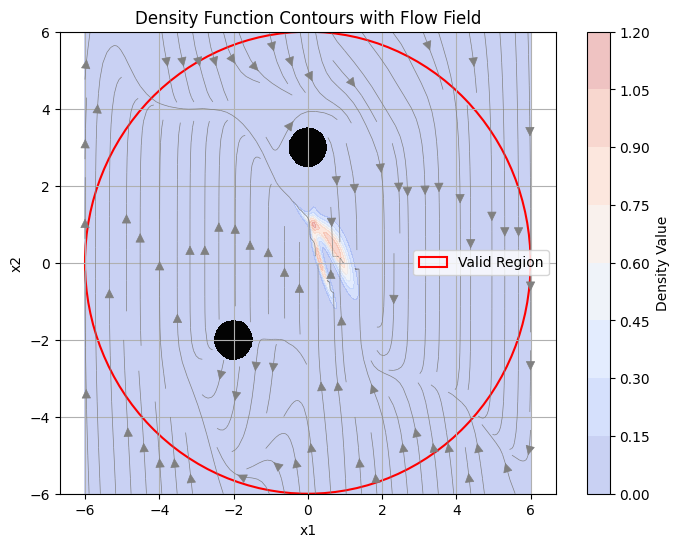

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [15]:
def plot_mixed_stable_safe_contours(a_nn,a_nn1,b_nn,b_nn1,c_nn,c_nn1, plot_flow=True):
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())

    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp(
            torch.sum( grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        
        rho_set1 = rho_set1 / max(rho_set1)

        rho_set2 = a_nn1(grid_points) / (torch.exp(
            torch.sum( grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set2 = rho_set2 / max(rho_set2)
        mixed_rho_set = rho_set1 + rho_set2
        mixed_rho_set = mixed_rho_set.squeeze().cpu().numpy().reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    filled_contours = ax.contourf(X, Y, mixed_rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X-0)**2 + (Y-3)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    unsafe_region2 = (X+2)**2 + (Y+2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region2, levels=[0.5, 1], colors='black', alpha=0.99)

    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            exp1 = (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            
            exp2 = (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            
            numerator = exp2 * c_nn(flow_points) + exp1 * c_nn1(flow_points)
            denominator = (exp2 * a_nn(flow_points) + exp1 * a_nn1(flow_points) + 1e-9)
            u_values = (numerator / denominator).squeeze()
            
            
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Mask the velocity field inside the unsafe region
        unsafe_mask = (X_flow - 0)**2 + (Y_flow - 3)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]

        # another unsafe region is (-2,-2)
        unsafe_mask = (X_flow + 2)**2 + (Y_flow + 2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]        
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    return fig, ax

plot_mixed_stable_safe_contours(a_safe_model, a_safe_model1, b_safe_model, b_safe_model1, c_safe_model, c_safe_model1, plot_flow=True)




# New unsafe set:
We consider an additional obstacle as following:
\begin{align}
    C_3^c=\{(x_1,x_2): (x_1-2)^2 +(x_2-2)^2  \leq 0.25\} \Rightarrow h(x)=(x_1-2)^2+(x_2-2)^2-0.25
\end{align}

In [19]:
def h2(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = (x[:,0]-2)**2 + (x[:,1]-2)**2 - 0.25
    return val.unsqueeze(0) if val.shape[0] == 1 else val

def control_safety_loss_h2(x,a_fun,c_fun,h_fun2):
    a_vals = a_fun(x).squeeze()
    c_vals = c_fun(x).squeeze()
    h_vals = h_fun2(x).squeeze()

    lie_derivative_g = 2 * (x[:,1]-2)
    lie_derivative_f = 2 * (x[:,0]-2)*x[:,1] + 2*(x[:,1]-2)*((x[:,0]-1)-(x[:,0]-1)**3 - 0.1 * x[:,1])
    first_constraint = a_vals * (lie_derivative_f + (h_vals **5))
    second_constraint = c_vals * lie_derivative_g
    safety_loss = F.relu( - (first_constraint + second_constraint)).mean()
    return safety_loss

def safe_density_training_2(x, epochs=100, lr=1e-4, ball_lb=0.05, ball_ub=6,check_interval=10):
    """ trains for safe and stable density functions and controller corresponding to it"""
    stability_loss = []
    safety_loss = []
    loss_total= []

    # call the neural networks
    a_net = numerator_polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
    b_net = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
    c_net = polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)

    gamma_net = GammaFunctionNet(input_dim=2, output_dim=1).to(device)
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5

    valid = False
    print("Starting training...")

    iteration_limit = 1000
    while not valid:
        for epoch in range(epochs):
            for iteration in range(iteration_limit):
                optimizer.zero_grad()

                loss_stability = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
                loss_safety = control_safety_loss_h2(x, a_net, c_net, h2)
                loss_reg = l2_for_b(x, b_net)
                total_loss = loss_stability + 10 * loss_safety + (1e-4) * loss_reg
                total_loss.backward()
                optimizer.step()
            if epoch % 1 == 0:
                print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Stability Loss: {loss_stability.item():.6f}, Safety Loss: {loss_safety.item():.6f}, Reg Loss: {loss_reg.item():.6f}")
                stability_loss.append(loss_stability.item())
                safety_loss.append(loss_safety.item())
                loss_total.append(total_loss.item())
            # Early stoping if the loss is already 1e-3, can stop
            if total_loss.item() < 1e-3:
                valid = True
                print(" Loss threshold met - stopping early!")
                break
    print("Training completed with valid constraints.")
    return a_net, b_net, c_net, stability_loss, safety_loss, loss_total

def plot_stable_safe_density_contours2(a_nn, b_nn, c_nn, density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = (1e+5)*a_nn(grid_points) / (torch.exp(
            torch.sum( grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X-2)**2 + (Y-2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Mask the velocity field inside the unsafe region
        unsafe_mask = (X_flow - 2)**2 + (Y_flow - 2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]
  
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax

In [20]:
torch.cuda.empty_cache()
torch.manual_seed(100)
random.seed()

numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float().to(device)

In [21]:
a_safe2, b_safe2, c_safe2, stability_loss_safe2, safety_loss_safe2, total_loss_safe2 = safe_density_training_2(numerical_x, epochs=60, lr=1e-4, ball_lb=0.05, ball_ub=6, check_interval=30)

Starting training...
Epoch 0, Total Loss: 1.287486, Stability Loss: 0.432389, Safety Loss: 0.085296, Reg Loss: 21.368916
Epoch 1, Total Loss: 0.544991, Stability Loss: 0.092867, Safety Loss: 0.045007, Reg Loss: 20.525187
Epoch 2, Total Loss: 0.242256, Stability Loss: 0.013630, Safety Loss: 0.022646, Reg Loss: 21.615076
Epoch 3, Total Loss: 0.102086, Stability Loss: 0.004165, Safety Loss: 0.009571, Reg Loss: 22.149529
Epoch 4, Total Loss: 0.065704, Stability Loss: 0.000822, Safety Loss: 0.006263, Reg Loss: 22.489218
Epoch 5, Total Loss: 0.052808, Stability Loss: 0.000011, Safety Loss: 0.005055, Reg Loss: 22.498440
Epoch 6, Total Loss: 0.046229, Stability Loss: 0.000028, Safety Loss: 0.004394, Reg Loss: 22.584923
Epoch 7, Total Loss: 0.037925, Stability Loss: 0.000000, Safety Loss: 0.003565, Reg Loss: 22.796368
Epoch 8, Total Loss: 0.029214, Stability Loss: 0.000000, Safety Loss: 0.002692, Reg Loss: 22.903206
Epoch 9, Total Loss: 0.021986, Stability Loss: 0.000000, Safety Loss: 0.001974,

In [22]:
torch.save(a_safe2.state_dict(), "a_safe_model2.pth")
torch.save(b_safe2.state_dict(), "b_safe_model2.pth")
torch.save(c_safe2.state_dict(), "c_safe_model2.pth")

In [23]:
a_safe_model2 = numerator_polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
a_safe_model2.load_state_dict(torch.load("a_safe_model2.pth"))
b_safe_model2 = polynomial_net(input_dim=2, hidden_dim=32, output_dim=2).to(device)
b_safe_model2.load_state_dict(torch.load("b_safe_model2.pth"))
c_safe_model2 = polynomial_net(input_dim=2, hidden_dim=16, output_dim=1).to(device)
c_safe_model2.load_state_dict(torch.load("c_safe_model2.pth"))

/tmp/ipykernel_80138/2327582640.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_safe_model2.load_state_dict(torch.load("a_safe_model2.pth"))
/tmp/ipykernel_80138/23275

<All keys matched successfully>

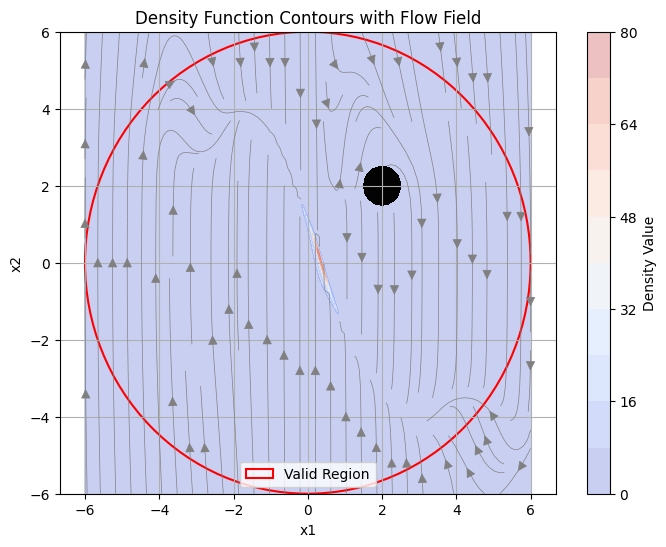

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [25]:
plot_stable_safe_density_contours2(a_safe_model2, b_safe_model2, c_safe_model2, density_threshold=0.1, device=device, plot_flow=True)

# learn a single controller for all 3 constraints

one single controller for each constraints

In [66]:
def safe_density_training_all_3(x, epochs=100, lr=1e-4, ball_lb=0.05, ball_ub=6,check_interval=10):
    """ trains for safe and stable density functions and controller corresponding to it"""
    stability_loss = []
    safety_loss = []
    loss_total= []

    # call the neural networks
    a_net = numerator_polynomial_net(input_dim=2, hidden_dim=32, output_dim=1).to(device)
    b_net = polynomial_net(input_dim=2, hidden_dim=64, output_dim=2).to(device)
    c_net = polynomial_net(input_dim=2, hidden_dim=32, output_dim=1).to(device)

    gamma_net = GammaFunctionNet(input_dim=2, output_dim=1).to(device)
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5

    valid = False
    print("Starting training...")



    iteration_limit = 1000
    while not valid:
        for epoch in range(epochs):
            for iteration in range(iteration_limit):
                optimizer.zero_grad()
                loss_stability = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
                
                loss_safety = control_safety_loss(x, a_net, c_net, h) + control_safety_loss_h1(x, a_net, c_net, h1) + control_safety_loss_h2(x,a_net,c_net,h2)

                loss_reg = l2_for_b(x, b_net)
                
                total_loss = loss_stability + 10 * loss_safety + (1e-4) * loss_reg
                total_loss.backward()
                optimizer.step()
            
            if epoch % 1 == 0:
                print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Stability Loss: {loss_stability.item():.6f}, Safety Loss: {loss_safety.item():.6f}, Reg Loss: {loss_reg.item():.6f}")
                stability_loss.append(loss_stability.item())
                safety_loss.append(loss_safety.item())
                loss_total.append(total_loss.item())
            
            # Early stoping if the loss is already 1e-3, can stop
            if total_loss.item() < 1e-3:
                valid = True
                print(" Loss threshold met - stopping early!")
                break
    print("Training completed with valid constraints.")
    return a_net, b_net, c_net, stability_loss, safety_loss, loss_total


def plot_stable_safe_density_contours_all_3(a_nn, b_nn, c_nn, density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = (1e+5)*a_nn(grid_points) / (torch.exp(
            torch.sum( grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X-0)**2 + (Y-3)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    
    unsafe_region2 = (X+2)**2 + (Y+2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region2, levels=[0.5, 1], colors='black', alpha=0.99)
    unsafe_region3 = (X-2)**2 + (Y-2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region3, levels=[0.5, 1], colors='black', alpha=0.99)
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Mask the velocity field inside the unsafe region
        unsafe_mask = (X_flow - 0)**2 + (Y_flow - 3)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]

        # another unsafe region is (-2,-2)
        unsafe_mask = (X_flow + 2)**2 + (Y_flow + 2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]        
        unsafe_mask = (X_flow - 2)**2 + (Y_flow - 2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]        
                
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax

a_safe_all, b_safe_all, c_safe_all, stability_loss_safe_all, safety_loss_safe_all, total_loss_safe_all = safe_density_training_all_3(numerical_x, epochs=60, lr=1e-4, ball_lb=0.05, ball_ub=6, check_interval=30)

Starting training...
Epoch 0, Total Loss: 1.132793, Stability Loss: 0.225393, Safety Loss: 0.090549, Reg Loss: 19.095617
Epoch 1, Total Loss: 0.195574, Stability Loss: 0.021153, Safety Loss: 0.017248, Reg Loss: 19.387087
Epoch 2, Total Loss: 0.095028, Stability Loss: 0.003743, Safety Loss: 0.008923, Reg Loss: 20.573536
Epoch 3, Total Loss: 0.057044, Stability Loss: 0.004537, Safety Loss: 0.005030, Reg Loss: 22.122059
Epoch 4, Total Loss: 0.032567, Stability Loss: 0.001952, Safety Loss: 0.002845, Reg Loss: 21.694338
Epoch 5, Total Loss: 0.019189, Stability Loss: 0.000629, Safety Loss: 0.001640, Reg Loss: 21.611900
Epoch 6, Total Loss: 0.013139, Stability Loss: 0.000375, Safety Loss: 0.001056, Reg Loss: 22.044790
Epoch 7, Total Loss: 0.009590, Stability Loss: 0.000386, Safety Loss: 0.000692, Reg Loss: 22.816620
Epoch 8, Total Loss: 0.007344, Stability Loss: 0.000777, Safety Loss: 0.000427, Reg Loss: 22.935343
Epoch 9, Total Loss: 0.005298, Stability Loss: 0.000031, Safety Loss: 0.000283,

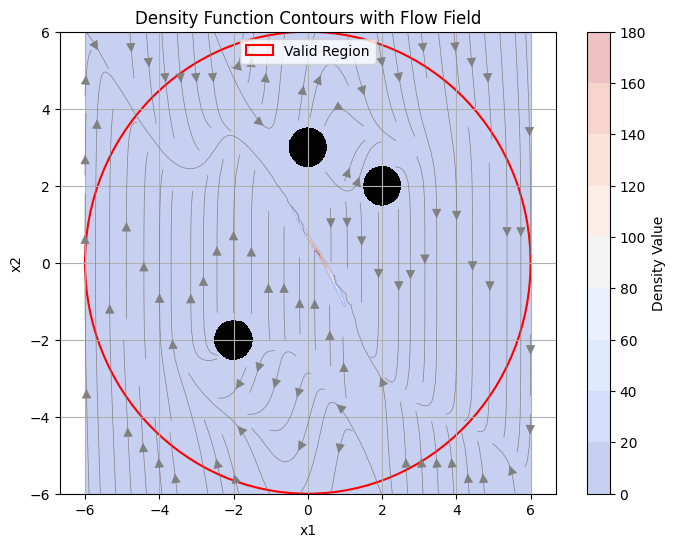

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Density Function Contours with Flow Field'}, xlabel='x1', ylabel='x2'>)

In [67]:
plot_stable_safe_density_contours_all_3(a_safe_all,b_safe_all,c_safe_all,density_threshold=0.1, device=device, plot_flow=True)